# Corner far-to-near sweep, fixed hyperparameters, 10 seeds

Companion to `ml_32_corner_far_to_near.ipynb` that checks how robust the sweep is to the random seed.

Instead of a fresh tuner search per fraction, this loads the per-fraction best hyperparameters ml_32 already found (from its seed 3 results CSV) and retrains one model per seed for 9 new seeds (1, 2, 4-10, seed 3 skipped since ml_32 already trained it, so 10 seeds total). Architecture / learning rate / dropout / L2 / penalty weight per fraction are identical across seeds, only weight init + shuffling change. That separates seed variance from the hyperparameter search variance ml_32 mixes in.

Per (fraction, seed):

1. rebuild the surrogate with that fractions tuner-best HP, train on the limited far-to-near subset
2. freeze it, rebuild + train the inverse with that fractions tuner-best inverse HP (same `qiskit_range_penalty` weight)

One results CSV per seed, same schema as ml_32 so ml_33/ml_34 can read them unchanged:

- `results/data_amount_sweep_corner/data_amount_sweep_corner_far_to_near_fixed_hp_seed{S}.csv`
- `results/data_amount_sweep_corner/data_amount_sweep_corner_far_to_near_fixed_hp_all_seeds_summary.csv` (mean/std across all 10 seeds incl. ml_32 seed 3)
- `model/corner_far_to_near_data_amount_sweep_fixed_hp/fraction_*pct_seed{S}_{surrogate,combined,inverse}.keras`

100% still means 100% of the non-held-out training pool, corner val/test samples always excluded.


## Validation loss per training slice, averaged across the 10 seeds

Quick look that only reads the saved sweep CSVs (no tensorflow, no training). Combines the nine fixed-HP per-seed CSVs from this notebook with the ml_32 keras-tuned seed 3 CSV, whose `*_tuner_best_val_loss` columns record the same quantity under a different name.


Seeds included: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
 training_percent  n_seeds  surrogate_val_loss_mean  surrogate_val_loss_std  surrogate_val_loss_median  inverse_val_loss_mean  inverse_val_loss_std  inverse_val_loss_median
               10       10                 0.024796                0.006675                   0.024336               0.037056              0.015361                 0.034762
               20       10                 0.015496                0.005928                   0.013912               0.006015              0.003423                 0.004961
               30       10                 0.018859                0.013234                   0.014491               0.005039              0.002308                 0.004543
               40       10                 0.015741                0.005293                   0.015864               0.003286              0.001847                 0.003397
               50       10                 0.033641                0.036659            

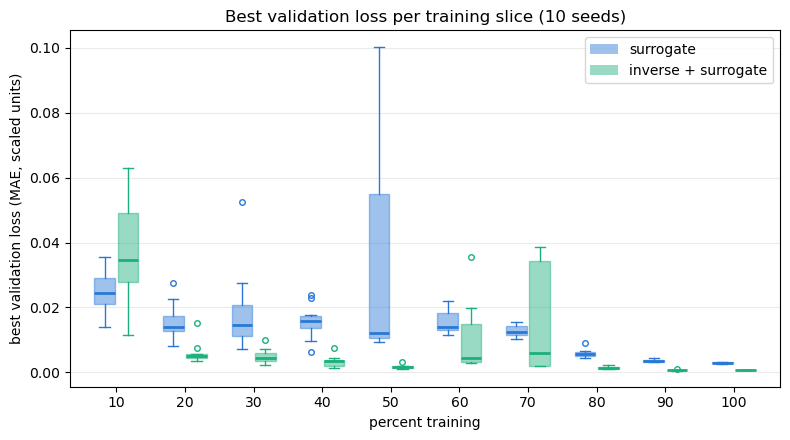

In [31]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

_SWEEP_DIR = Path.cwd()
_VAL_LOSS_COLS = ["fraction", "seed", "surrogate_best_val_loss", "inverse_best_val_loss"]

_frames = [
    pd.read_csv(p)[_VAL_LOSS_COLS]
    for p in sorted(_SWEEP_DIR.glob("results/data_amount_sweep_corner/data_amount_sweep_corner_far_to_near_fixed_hp_seed*.csv"))
]

## seed 3 comes from the ml_32 tuner run; its val-loss columns use the tuner_ prefix
_seed3_csv = _SWEEP_DIR / "results/data_amount_sweep_corner/data_amount_sweep_corner_far_to_near_retrained_surrogate_seed3.csv"
if _seed3_csv.exists():
    _frames.append(
        pd.read_csv(_seed3_csv)
        .rename(columns={
            "surrogate_tuner_best_val_loss": "surrogate_best_val_loss",
            "inverse_tuner_best_val_loss": "inverse_best_val_loss",
        })[_VAL_LOSS_COLS]
    )

val_loss_by_seed = pd.concat(_frames, ignore_index=True)
val_loss_by_seed["training_percent"] = (val_loss_by_seed["fraction"] * 100).round().astype(int)

val_loss_summary = (
    val_loss_by_seed.groupby("training_percent")
    .agg(
        n_seeds=("seed", "nunique"),
        surrogate_val_loss_mean=("surrogate_best_val_loss", "mean"),
        surrogate_val_loss_std=("surrogate_best_val_loss", "std"),
        surrogate_val_loss_median=("surrogate_best_val_loss", "median"),
        inverse_val_loss_mean=("inverse_best_val_loss", "mean"),
        inverse_val_loss_std=("inverse_best_val_loss", "std"),
        inverse_val_loss_median=("inverse_best_val_loss", "median"),
    )
    .reset_index()
)

print(f"Seeds included: {sorted(val_loss_by_seed['seed'].unique())}")
print(val_loss_summary.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

_percents = sorted(val_loss_by_seed["training_percent"].unique())
_series = [
    ("surrogate_best_val_loss", "surrogate", "#2a78d6", -0.17),
    ("inverse_best_val_loss", "inverse + surrogate", "#1baf7a", 0.17),
]

fig, ax = plt.subplots(figsize=(8, 4.5))
for col, label, color, offset in _series:
    data = [
        val_loss_by_seed.loc[val_loss_by_seed["training_percent"] == p, col].dropna()
        for p in _percents
    ]
    ax.boxplot(
        data,
        positions=np.arange(len(_percents)) + offset,
        widths=0.3,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.45, color=color),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        medianprops=dict(color=color, linewidth=2),
        flierprops=dict(markeredgecolor=color, markersize=4),
    )
ax.set_xticks(np.arange(len(_percents)))
ax.set_xticklabels(_percents)
ax.set_xlabel("percent training")
ax.set_ylabel("best validation loss (MAE, scaled units)")
ax.set_title(f"Best validation loss per training slice ({val_loss_summary['n_seeds'].min()} seeds)")
ax.legend(handles=[Patch(facecolor=c, alpha=0.45, label=l) for _, l, c, _ in _series])
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

In [32]:
from __future__ import annotations

import gc
import json
import os
import sys
import zipfile
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
## Use the async CUDA allocator to avoid fragmentation OOMs over the long
## multi-fraction tuner loop. Must be set before TensorFlow touches the GPU.
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")

import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import keras_tuner as kt
from sklearn.neighbors import NearestNeighbors
from tensorflow.keras import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Input, LeakyReLU
from tensorflow.keras.models import load_model


tf.keras.backend.set_floatx("float32")

## Let GPU memory grow on demand instead of pre-reserving it all, which also
## reduces fragmentation OOMs during the long search.
for _gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except Exception:
        pass


## This notebook can be run either from the transmon experiment folder or from the
## repo root. The block below tries both so local paths do not need hard-coding.
HERE = Path.cwd()
EXPERIMENT_RELATIVE = Path("experiments/model_predict_qubit_TransmonCross_Hamiltonian_params")

if (HERE / "metadata" / "qubit-TransmonCross-Hamiltonian_params.json").exists():
    EXPERIMENT_DIR = HERE
elif (HERE / EXPERIMENT_RELATIVE / "metadata" / "qubit-TransmonCross-Hamiltonian_params.json").exists():
    EXPERIMENT_DIR = HERE / EXPERIMENT_RELATIVE
else:
    raise FileNotFoundError(
        "Could not find the transmon-cross metadata file. "
        "Run this notebook from the repo root or from the transmon experiment folder."
    )

if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

from parameters_surrogate_defined_loss import (  # noqa: E402
    EPOCHS,
    KT_DIR,
    MODEL_DIR as PARAM_MODEL_DIR,
    SCALERS_DIR as PARAM_SCALERS_DIR,
    TRAIN_BATCH_SIZE,
    TRAIN_EARLY_STOPPING_PATIENCE,
    TRAIN_LOSS,
)
from parameters_surrogate import (  # noqa: E402
    EPOCHS as SURROGATE_EPOCHS,
    TRAIN_BATCH_SIZE as SURROGATE_TRAIN_BATCH_SIZE,
    TRAIN_EARLY_STOPPING_PATIENCE as SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE,
    TRAIN_LOSS as SURROGATE_TRAIN_LOSS,
)

METADATA_DIR = EXPERIMENT_DIR / "metadata"
METADATA_PATH = METADATA_DIR / "qubit-TransmonCross-Hamiltonian_params.json"
## Per-fraction best hyperparameters are read from the completed ml_32 tuner sweep.
## seed 3 is the run that finished all ten fractions. Only the seed varies in this
## notebook; each fraction's architecture/LR/etc. are frozen to its tuner-best values.
HP_SOURCE_CSV = EXPERIMENT_DIR / "results/data_amount_sweep_corner/data_amount_sweep_corner_far_to_near_retrained_surrogate_seed3.csv"
## one results CSV is written per seed (see out_path_for_seed); this is the across-seed roll-up.
COMBINED_SUMMARY_OUT_PATH = EXPERIMENT_DIR / "results/data_amount_sweep_corner/data_amount_sweep_corner_far_to_near_fixed_hp_all_seeds_summary.csv"

MODEL_DIR = Path(PARAM_MODEL_DIR)
SCALERS_DIR = Path(PARAM_SCALERS_DIR)
SWEEP_MODEL_DIR = MODEL_DIR / "corner_far_to_near_data_amount_sweep_fixed_hp"
SWEEP_MODEL_DIR.mkdir(parents=True, exist_ok=True)
SURROGATE_MODEL_PATH = MODEL_DIR / "best_keras_model_model2_surrogate.keras"
COMBINED_MODEL_CANDIDATES = [
    MODEL_DIR / "surrogate_loss_2in_3out_best_model.keras",
    MODEL_DIR / "best_keras_model_surrogate_defined_loss.keras",
]
COMBINED_MODEL_PATH = next((path for path in COMBINED_MODEL_CANDIDATES if path.exists()), None)
if COMBINED_MODEL_PATH is None:
    raise FileNotFoundError(f"No reference combined inverse+surrogate model found in {MODEL_DIR}")
INVERSE_MODEL_PATH = COMBINED_MODEL_PATH
ACTIVE_SURROGATE_MODEL_PATH = SURROGATE_MODEL_PATH

## Retrain a fresh surrogate for each limited training subset, then freeze it
## while training the inverse model for that same subset.
RETRAIN_SURROGATE_PER_SUBSET = True

## sweep all ten training-pool fractions (10% ... 100%).
FRACTIONS = tuple(round(0.1 * i, 2) for i in range(1, 11))
## 9 new seeds, one model per seed, all using the fixed per-fraction HP from HP_SOURCE_CSV.
## Seed 3 is intentionally excluded: ml_32 already trained it, so the two together give 10 seeds.
ALREADY_TRAINED_SEED = 3
SEEDS = tuple(s for s in range(1, 11) if s != ALREADY_TRAINED_SEED)

## Keras-tuner hyperparameter search per fraction. 50 surrogate + 50 inverse trials
## = 100 trials per fraction (1000 trials across the ten fractions).
## The surrogate search space mirrors ml_11; the inverse search space mirrors ml_21.
KERAS_TUNER_TRIALS_SURROGATE = 50
KERAS_TUNER_TRIALS_INVERSE = 50
KERAS_TUNER_EXECUTIONS_PER_TRIAL = 1
## Tolerate a few transient OOM/failed trials before a search gives up.
KERAS_TUNER_MAX_CONSEC_FAILURES = 8
## Resume (do not overwrite) so an interrupted long sweep can continue where it left off.
## Set to True to discard existing tuner trials and start the search from scratch.
KERAS_TUNER_OVERWRITE = False
TUNER_DIR = Path(KT_DIR) / "corner_far_to_near_sweep"
TUNER_DIR.mkdir(parents=True, exist_ok=True)

REQUESTED_TEST_CORNER_UM = np.array([50.0, 2.0, 420.0])

## I keep test and validation in the same corner region so the validation/test
## losses answer the same question: how well do we learn near the held-out corner?
TEST_FRACTION = 0.15
VAL_FRACTION = 0.15

## run the training sweep. Set this to False if the CSV already exists and you
## only want to remake the plots.
RUN_SWEEP = True

EPS = 1e-12

In [33]:
## data leading

@dataclass
class Scaler:
    min_: np.ndarray
    max_: np.ndarray

    @property
    def range_(self) -> np.ndarray:
        return np.maximum(self.max_ - self.min_, EPS)

    def transform(self, x: np.ndarray) -> np.ndarray:
        return (x - self.min_) / self.range_

    def inverse_transform(self, x: np.ndarray) -> np.ndarray:
        return x * self.range_ + self.min_


def parse_um(value: object) -> float:
    text = str(value).strip()
    for suffix in ("um", "µm", "μm"):
        if text.endswith(suffix):
            return float(text[: -len(suffix)])
    return float(text)


## Load Hamiltonian targets and geometry values from the SQuADDS metadata
def load_arrays() -> tuple[np.ndarray, np.ndarray]:
    data = json.loads(METADATA_PATH.read_text())
    hamiltonian = []
    geometry = []

    for row in data:
        h = row["Hamiltonian_params"]
        opts = row["design"]["design_options"]
        readout = opts["connection_pads"]["readout"]

        hamiltonian.append(
            [
                float(h["qubit_frequency_GHz"]),
                float(h["anharmonicity_MHz"]),
            ]
        )
        geometry.append(
            [
                parse_um(readout["claw_length"]),
                parse_um(readout["ground_spacing"]),
                parse_um(opts["cross_length"]),
            ]
        )

    return np.asarray(hamiltonian, dtype=np.float64), np.asarray(geometry, dtype=np.float64)


def choose_corner_heldout_split(
    geometry_um: np.ndarray,
    requested_corner_um: np.ndarray,
    test_fraction: float = 0.15,
    val_fraction: float = 0.15,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Choose a held-out corner region and keep the remaining points as training candidates.

    The requested corner is clipped to the actual data range because the collaborator's
    approximate values were read by eye and can sit slightly outside the sampled range.
    """
    n_rows = len(geometry_um)
    n_test = int(np.ceil(test_fraction * n_rows))
    n_val = int(np.ceil(val_fraction * n_rows))

    geom_min = geometry_um.min(axis=0)
    geom_max = geometry_um.max(axis=0)
    clipped_corner_um = np.clip(requested_corner_um, geom_min, geom_max)

    corner_scaler = Scaler(geom_min, geom_max)
    geometry_scaled = corner_scaler.transform(geometry_um)
    corner_scaled = corner_scaler.transform(clipped_corner_um.reshape(1, -1))[0]

    corner_distance = np.linalg.norm(geometry_scaled - corner_scaled, axis=1)
    near_corner_order = np.argsort(corner_distance)
    
    corner_idx = near_corner_order[:n_test + n_val]
    rng = np.random.default_rng(42)
    rng.shuffle(corner_idx)
    
    test_idx = corner_idx[:n_test]
    val_idx = corner_idx[n_test:]
    train_pool_idx = near_corner_order[n_test + n_val:]

    return train_pool_idx, val_idx, test_idx, clipped_corner_um, corner_distance


def rank_training_far_to_near(
    geometry_scaled: np.ndarray,
    train_pool_idx: np.ndarray,
    test_idx: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Rank the training pool by distance to the held-out test corner.

    The first samples are the farthest from the testing data. As the fraction
    increases, the subset grows toward the testing data.
    """
    train_geom = geometry_scaled[train_pool_idx]
    test_geom = geometry_scaled[test_idx]

    nn = NearestNeighbors(n_neighbors=1).fit(test_geom)
    train_to_test_distance = nn.kneighbors(train_geom, return_distance=True)[0][:, 0]
    far_to_near_order = np.argsort(-train_to_test_distance)

    return far_to_near_order, train_to_test_distance


def scaler_from_artifacts(
    values: np.ndarray,
    columns: list[str],
    path_patterns: list[str],
    label: str,
) -> tuple[Scaler, list[str]]:
    """Load per-column MinMaxScaler ranges when present, otherwise fit on metadata."""
    mins = []
    maxs = []
    sources = []

    for i, col in enumerate(columns):
        loaded = None
        source = None
        for pattern in path_patterns:
            candidate = SCALERS_DIR / pattern.format(col=col)
            if candidate.exists():
                loaded = joblib.load(candidate)
                source = str(candidate)
                break

        if loaded is not None:
            mins.append(float(np.asarray(loaded.data_min_).reshape(-1)[0]))
            maxs.append(float(np.asarray(loaded.data_max_).reshape(-1)[0]))
            sources.append(source)
        else:
            mins.append(float(np.min(values[:, i])))
            maxs.append(float(np.max(values[:, i])))
            sources.append(f"metadata fallback: {label}.{col}")

    return Scaler(np.asarray(mins), np.asarray(maxs)), sources


In [34]:
## builing the split and scalars

h_raw, geom_raw_um = load_arrays()
geom_raw_si = geom_raw_um * 1e-6

HAMILTONIAN_COLUMN_NAMES = (METADATA_DIR / "X_names").read_text().splitlines()
QISKIT_PARAM_NAMES = np.load(METADATA_DIR / "y_columns.npy", allow_pickle=True).astype(str).tolist()

train_pool_idx, val_idx, test_idx, clipped_corner_um, corner_distance = choose_corner_heldout_split(
    geom_raw_um,
    REQUESTED_TEST_CORNER_UM,
    TEST_FRACTION,
    VAL_FRACTION,
)

## Make sure the held-out corner data never leaks into the inverse-model training pool.
assert len(np.intersect1d(train_pool_idx, val_idx)) == 0
assert len(np.intersect1d(train_pool_idx, test_idx)) == 0
assert len(np.intersect1d(val_idx, test_idx)) == 0

## the split/ranking scaler is only for choosing far-to-near geometry coverage.
## it is fit on the non-held-out training pool only.
geom_split_scaler = Scaler(
    geom_raw_um[train_pool_idx].min(axis=0),
    geom_raw_um[train_pool_idx].max(axis=0),
)
geom_scaled = geom_split_scaler.transform(geom_raw_um)

far_to_near_order, train_to_test_distance = rank_training_far_to_near(
    geom_scaled,
    train_pool_idx,
    test_idx,
)

## For the actual model inputs/outputs, use the saved scaler artifacts from the
## existing repo workflow. This keeps the already trained surrogate in the same
## scaled space it was originally trained in.
h_model_scaler, h_scaler_sources = scaler_from_artifacts(
    h_raw,
    HAMILTONIAN_COLUMN_NAMES,
    ["scaler_X_{col}.save", "scaler_X_linear_{col}.save"],
    "Hamiltonian",
)
geom_inverse_scaler, geom_inverse_scaler_sources = scaler_from_artifacts(
    geom_raw_si,
    QISKIT_PARAM_NAMES,
    ["scaler_y_{col}_one_hot_encoding.save"],
    "inverse_qiskit",
)
geom_surrogate_scaler, geom_surrogate_scaler_sources = scaler_from_artifacts(
    geom_raw_si,
    QISKIT_PARAM_NAMES,
    ["scaler_y_linear_{col}.save", "scaler_y_{col}_one_hot_encoding.save"],
    "surrogate_qiskit",
)

h_model_scaled = h_model_scaler.transform(h_raw).astype("float32")
geom_inverse_scaled = geom_inverse_scaler.transform(geom_raw_si).astype("float32")
geom_surrogate_scaled = geom_surrogate_scaler.transform(geom_raw_si).astype("float32")

## Convert inverse output scaler space to surrogate input scaler space.
## surrogate_scaled = inverse_scaled * scale_a + scale_b
scale_a = (geom_inverse_scaler.range_ / geom_surrogate_scaler.range_).astype("float32")
scale_b = ((geom_inverse_scaler.min_ - geom_surrogate_scaler.min_) / geom_surrogate_scaler.range_).astype("float32")

print(f"Loaded {len(h_raw)} total samples")
print(f"Training pool: {len(train_pool_idx)}")
print(f"Validation corner: {len(val_idx)}")
print(f"Test corner: {len(test_idx)}")
print()
print("Split check passed:")
print("  train/val overlap:", len(np.intersect1d(train_pool_idx, val_idx)))
print("  train/test overlap:", len(np.intersect1d(train_pool_idx, test_idx)))
print("  val/test overlap:", len(np.intersect1d(val_idx, test_idx)))
print("  100% means all non-held-out training-pool samples, not all samples.")
print()
print("Requested corner [um]:", REQUESTED_TEST_CORNER_UM)
print("Used clipped corner [um]:", clipped_corner_um)
print()
print("Using saved model-space scalers from the existing repo workflow.")
for name, lo, hi, source in zip(HAMILTONIAN_COLUMN_NAMES, h_model_scaler.min_, h_model_scaler.max_, h_scaler_sources):
    print(f"  Hamiltonian {name}: {lo:.6g} to {hi:.6g}  ({source})")
for name, lo, hi, source in zip(QISKIT_PARAM_NAMES, geom_inverse_scaler.min_, geom_inverse_scaler.max_, geom_inverse_scaler_sources):
    print(f"  Inverse geometry {name}: {lo:.6g} to {hi:.6g} SI units  ({source})")
for name, lo, hi, source in zip(QISKIT_PARAM_NAMES, geom_surrogate_scaler.min_, geom_surrogate_scaler.max_, geom_surrogate_scaler_sources):
    print(f"  Surrogate geometry {name}: {lo:.6g} to {hi:.6g} SI units  ({source})")

if any(source.startswith("metadata fallback") for source in h_scaler_sources + geom_inverse_scaler_sources + geom_surrogate_scaler_sources):
    print()
    print("Note: at least one scaler artifact was not found, so metadata-derived min/max ranges were used for that column.")


Loaded 1934 total samples
Training pool: 1352
Validation corner: 291
Test corner: 291

Split check passed:
  train/val overlap: 0
  train/test overlap: 0
  val/test overlap: 0
  100% means all non-held-out training-pool samples, not all samples.

Requested corner [um]: [ 50.   2. 420.]
Used clipped corner [um]: [ 70.    4.1 420. ]

Using saved model-space scalers from the existing repo workflow.
  Hamiltonian qubit_frequency_GHz: 3.21853 to 7.12659  (/home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/scalers/scaler_X_qubit_frequency_GHz.save)
  Hamiltonian anharmonicity_MHz: -525.818 to -88.9577  (/home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/scalers/scaler_X_anharmonicity_MHz.save)
  Inverse geometry design_options.connection_pads.readout.claw_length: 7e-05 to 0.0004 SI units  (/home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/scalers/scaler_y_desig

In [35]:

def read_keras_config(path: Path) -> dict:
    with zipfile.ZipFile(path) as zf:
        return json.loads(zf.read("config.json"))


def extract_reference_specs(combined_path: Path) -> tuple[dict, dict]:
    cfg = read_keras_config(combined_path)
    layers = cfg["config"]["layers"]
    inverse_cfg = next(
        layer for layer in layers
        if layer.get("class_name") == "Sequential" and layer.get("config", {}).get("name") == "inverse_model"
    )
    compile_cfg = cfg.get("compile_config") or {}
    return inverse_cfg["config"], compile_cfg


def extract_surrogate_specs(surrogate_path: Path) -> tuple[dict, dict]:
    cfg = read_keras_config(surrogate_path)
    if cfg.get("class_name") != "Sequential":
        raise ValueError(f"Expected a Sequential surrogate model, got {cfg.get('class_name')} from {surrogate_path}")
    return cfg["config"], cfg.get("compile_config") or {}


def _initializer_from_config(config: dict | None, seed: int | None):
    if not config:
        return None
    cfg = json.loads(json.dumps(config))
    if seed is not None and isinstance(cfg.get("config"), dict) and "seed" in cfg["config"]:
        cfg["config"]["seed"] = seed
    try:
        return tf.keras.initializers.deserialize(cfg)
    except Exception:
        class_name = cfg.get("class_name")
        if class_name == "HeNormal":
            return tf.keras.initializers.HeNormal(seed=cfg.get("config", {}).get("seed"))
        if class_name == "LecunUniform":
            return tf.keras.initializers.LecunUniform(seed=cfg.get("config", {}).get("seed"))
        if class_name == "Zeros":
            return tf.keras.initializers.Zeros()
        return tf.keras.initializers.get(class_name)


def _regularizer_from_config(config: dict | None):
    if not config:
        return None
    try:
        return tf.keras.regularizers.deserialize(config)
    except Exception:
        if config.get("class_name") == "L2":
            return tf.keras.regularizers.l2(config.get("config", {}).get("l2", 0.01))
        raise


def build_sequential_from_config(config: dict, input_dim: int, seed: int, default_name: str) -> Sequential:
    tf.keras.utils.set_random_seed(seed)
    model = Sequential(name=config.get("name", default_name))
    for layer_idx, layer_cfg in enumerate(config["layers"]):
        class_name = layer_cfg["class_name"]
        cfg = layer_cfg["config"]
        if class_name == "InputLayer":
            model.add(Input(shape=(input_dim,), name=cfg.get("name", "input")))
        elif class_name == "Dense":
            model.add(
                Dense(
                    cfg["units"],
                    activation=cfg.get("activation", "linear"),
                    name=cfg.get("name"),
                    kernel_initializer=_initializer_from_config(cfg.get("kernel_initializer"), seed + layer_idx),
                    bias_initializer=_initializer_from_config(cfg.get("bias_initializer"), None),
                    kernel_regularizer=_regularizer_from_config(cfg.get("kernel_regularizer")),
                    bias_regularizer=_regularizer_from_config(cfg.get("bias_regularizer")),
                )
            )
        elif class_name == "LeakyReLU":
            model.add(LeakyReLU(negative_slope=cfg.get("negative_slope", 0.01), name=cfg.get("name")))
        elif class_name == "Dropout":
            model.add(Dropout(rate=cfg.get("rate", 0.0), name=cfg.get("name")))
        else:
            raise ValueError(f"Unsupported reference layer type: {class_name}")
    return model


def build_inverse_from_reference(input_dim: int, seed: int) -> Sequential:
    return build_sequential_from_config(REFERENCE_INVERSE_CONFIG, input_dim, seed, "inverse_model")


def build_surrogate_from_reference(input_dim: int, seed: int) -> Sequential:
    model = build_sequential_from_config(SURROGATE_REFERENCE_CONFIG, input_dim, seed, "retrained_surrogate")
    model.compile(
        optimizer=build_surrogate_optimizer(),
        loss=SURROGATE_RECONSTRUCTION_LOSS,
        metrics=[SURROGATE_TRAIN_LOSS],
        jit_compile=SURROGATE_JIT_COMPILE,
    )
    return model


class ScalerConversionLayer(tf.keras.layers.Layer):
    def __init__(self, scale_a, scale_b, **kwargs):
        kwargs.setdefault("trainable", False)
        super().__init__(**kwargs)
        self._scale_a = tf.constant(scale_a, dtype=tf.float32)
        self._scale_b = tf.constant(scale_b, dtype=tf.float32)
        self._cfg = {"scale_a": list(np.asarray(scale_a, dtype=float)), "scale_b": list(np.asarray(scale_b, dtype=float))}

    def call(self, inputs):
        a = tf.cast(self._scale_a, inputs.dtype)
        b = tf.cast(self._scale_b, inputs.dtype)
        return inputs * a + b

    def get_config(self):
        config = super().get_config()
        config.update(self._cfg)
        return config


## penalize inverse predictions outside the scaled [0, 1] training range
def qiskit_range_penalty(y_true_dummy, y_pred):
    below = tf.nn.relu(-y_pred)
    above = tf.nn.relu(y_pred - 1.0)
    return tf.reduce_mean(below ** 2 + above ** 2)


def load_frozen_surrogate(surrogate_model_path: Path):
    surrogate_model = load_model(surrogate_model_path, compile=False)
    surrogate_model.trainable = False
    for layer in surrogate_model.layers:
        layer.trainable = False
    return surrogate_model


def deserialize_reference_learning_rate(lr_config):
    if isinstance(lr_config, (int, float, np.integer, np.floating)):
        return float(lr_config)
    if isinstance(lr_config, str):
        try:
            return float(lr_config)
        except ValueError:
            return lr_config
    if isinstance(lr_config, dict):
        cfg = lr_config.get("config", {})
        for key in ("value", "initial_value"):
            if key in cfg and isinstance(cfg[key], (int, float, np.integer, np.floating)):
                return float(cfg[key])
        try:
            return tf.keras.optimizers.schedules.deserialize(lr_config)
        except Exception:
            if "initial_learning_rate" in cfg:
                return tf.keras.optimizers.schedules.ExponentialDecay(
                    initial_learning_rate=float(cfg["initial_learning_rate"]),
                    decay_steps=cfg.get("decay_steps", 1),
                    decay_rate=cfg.get("decay_rate", 1.0),
                    staircase=cfg.get("staircase", False),
                )
            raise
    return lr_config


def describe_learning_rate(lr) -> str:
    if isinstance(lr, (int, float, np.integer, np.floating)):
        return str(float(lr))
    if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
        return f"{lr.__class__.__name__}({lr.get_config()})"
    return str(lr)


def optimizer_lr_label(compile_config: dict) -> str:
    try:
        lr_cfg = compile_config["optimizer"]["config"]["learning_rate"]
        return describe_learning_rate(deserialize_reference_learning_rate(lr_cfg))
    except Exception:
        return "unknown"


def build_reference_optimizer():
    try:
        return tf.keras.optimizers.deserialize(REFERENCE_COMPILE_CONFIG["optimizer"])
    except Exception:
        return tf.keras.optimizers.Adam(learning_rate=REFERENCE_LEARNING_RATE)


def build_surrogate_optimizer():
    try:
        return tf.keras.optimizers.deserialize(SURROGATE_COMPILE_CONFIG["optimizer"])
    except Exception:
        return tf.keras.optimizers.Adam()


def build_combined_model(seed: int, surrogate_model_path: Path) -> tuple[Sequential, Model]:
    tf.keras.backend.clear_session()
    surrogate_model = load_frozen_surrogate(surrogate_model_path)
    inverse_model = build_inverse_from_reference(h_model_scaled.shape[1], seed=seed)

    combined_input = Input(shape=(h_model_scaled.shape[1],), name="combined_input")
    predicted_qiskit = inverse_model(combined_input)
    predicted_qiskit_converted = ScalerConversionLayer(scale_a, scale_b, name="scaler_conversion")(predicted_qiskit)
    reconstructed_hamiltonian = surrogate_model(predicted_qiskit_converted)

    combined_model = Model(
        inputs=combined_input,
        outputs=[reconstructed_hamiltonian, predicted_qiskit],
        name="combined_model",
    )

    combined_model.compile(
        optimizer=build_reference_optimizer(),
        loss=[REFERENCE_RECONSTRUCTION_LOSS, qiskit_range_penalty],
        loss_weights=REFERENCE_LOSS_WEIGHTS,
        jit_compile=REFERENCE_JIT_COMPILE,
    )

    return inverse_model, combined_model


REFERENCE_INVERSE_CONFIG, REFERENCE_COMPILE_CONFIG = extract_reference_specs(COMBINED_MODEL_PATH)
SURROGATE_REFERENCE_CONFIG, SURROGATE_COMPILE_CONFIG = extract_surrogate_specs(SURROGATE_MODEL_PATH)

REFERENCE_OPTIMIZER_CONFIG = REFERENCE_COMPILE_CONFIG["optimizer"]["config"]
REFERENCE_LEARNING_RATE = deserialize_reference_learning_rate(REFERENCE_OPTIMIZER_CONFIG["learning_rate"])
REFERENCE_LEARNING_RATE_LABEL = describe_learning_rate(REFERENCE_LEARNING_RATE)
REFERENCE_RECONSTRUCTION_LOSS = REFERENCE_COMPILE_CONFIG["loss"][0]
REFERENCE_LOSS_WEIGHTS = [float(v) for v in REFERENCE_COMPILE_CONFIG.get("loss_weights", [1.0, 1.0])]
## Pin the out-of-range (qiskit_range_penalty) weight to the best optimized value
## from the ml_21 Keras-tuner search. The best trial (val loss 0.001002) used
## penalty_weight = 1.0, matching the saved best combined model loss_weights.
## Setting it explicitly keeps this sweep identical to the best model regardless
## of which reference model file is loaded.
BEST_PENALTY_WEIGHT = 1.0
REFERENCE_LOSS_WEIGHTS = [REFERENCE_LOSS_WEIGHTS[0], BEST_PENALTY_WEIGHT]
REFERENCE_JIT_COMPILE = bool(REFERENCE_COMPILE_CONFIG.get("jit_compile", False))
REFERENCE_BATCH_SIZE = TRAIN_BATCH_SIZE
REFERENCE_EPOCHS = EPOCHS
REFERENCE_EARLY_STOPPING_PATIENCE = TRAIN_EARLY_STOPPING_PATIENCE

SURROGATE_RECONSTRUCTION_LOSS = SURROGATE_COMPILE_CONFIG.get("loss", SURROGATE_TRAIN_LOSS)
SURROGATE_LEARNING_RATE_LABEL = optimizer_lr_label(SURROGATE_COMPILE_CONFIG)
SURROGATE_JIT_COMPILE = bool(SURROGATE_COMPILE_CONFIG.get("jit_compile", False))

reference_dense_layers = [
    layer["config"]["units"]
    for layer in REFERENCE_INVERSE_CONFIG["layers"]
    if layer["class_name"] == "Dense"
]
surrogate_dense_layers = [
    layer["config"]["units"]
    for layer in SURROGATE_REFERENCE_CONFIG["layers"]
    if layer["class_name"] == "Dense"
]
print("Reference inverse dense units:", reference_dense_layers)
print("Reference inverse learning rate:", REFERENCE_LEARNING_RATE_LABEL)
print("Reference inverse reconstruction loss:", REFERENCE_RECONSTRUCTION_LOSS)
print("Reference inverse loss weights:", REFERENCE_LOSS_WEIGHTS)
print("Reference inverse jit_compile:", REFERENCE_JIT_COMPILE)
print("Inverse epochs/batch/patience:", REFERENCE_EPOCHS, REFERENCE_BATCH_SIZE, REFERENCE_EARLY_STOPPING_PATIENCE)
print()
print("Reference surrogate dense units:", surrogate_dense_layers)
print("Reference surrogate learning rate:", SURROGATE_LEARNING_RATE_LABEL)
print("Reference surrogate loss:", SURROGATE_RECONSTRUCTION_LOSS)
print("Reference surrogate jit_compile:", SURROGATE_JIT_COMPILE)
print("Surrogate epochs/batch/patience:", SURROGATE_EPOCHS, SURROGATE_TRAIN_BATCH_SIZE, SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE)


Reference inverse dense units: [64, 3]
Reference inverse learning rate: ExponentialDecay({'initial_learning_rate': 0.001, 'decay_steps': 220, 'decay_rate': 0.99, 'staircase': False, 'name': 'ExponentialDecay'})
Reference inverse reconstruction loss: mae
Reference inverse loss weights: [1.0, 1.0]
Reference inverse jit_compile: True
Inverse epochs/batch/patience: 400 128 60

Reference surrogate dense units: [736, 2]
Reference surrogate learning rate: 0.05013880506157875
Reference surrogate loss: mae
Reference surrogate jit_compile: True
Surrogate epochs/batch/patience: 400 128 60


In [36]:
## Keras-tuner hyperparameter search for the surrogate and the inverse+surrogate
## models. The surrogate search space mirrors ml_11_train_keras_surrogate.ipynb and
## the inverse search space mirrors ml_21_train_keras_surrogate_defined_loss.ipynb.

## surrogate (geometry -> Hamiltonian) hypermodel, search space from ml_11
def make_surrogate_hypermodel(input_dim: int, output_dim: int):
    def build(hp):
        tf.keras.backend.clear_session()
        gc.collect()

        n_layers = hp.Int("n_layers", min_value=1, max_value=1, default=1)
        neurons_per_layer = [hp.Int(f"neurons_{i}", min_value=32, max_value=1024, step=32) for i in range(n_layers)]
        dropout_rate = hp.Float("dropout_rate", 0.0, 0.45, step=0.05)
        l2_reg = hp.Float("l2_reg", 1e-5, 1e-2, sampling="LOG", default=1e-4)
        lr_initial = hp.Float("learning_rate", 3e-2, 1e-1, sampling="LOG", default=3e-2)
        use_batchnorm = hp.Boolean("use_batchnorm", default=True)

        model = Sequential(name="retrained_surrogate")
        model.add(Input(shape=(input_dim,), name="input1"))
        for i, n_units in enumerate(neurons_per_layer):
            model.add(Dense(n_units, name=f"fc{i}", kernel_initializer="he_normal",
                            kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
            if use_batchnorm:
                model.add(tf.keras.layers.BatchNormalization(name=f"bn{i}"))
            model.add(LeakyReLU(negative_slope=0.01, name=f"leaky_relu{i}"))
            model.add(Dropout(rate=dropout_rate, name=f"dropout{i}"))
        model.add(Dense(output_dim, name="output", kernel_initializer="he_normal"))
        model.compile(optimizer=tf.optimizers.Adam(learning_rate=lr_initial),
                      loss=SURROGATE_TRAIN_LOSS, metrics=[SURROGATE_TRAIN_LOSS])
        return model
    return build


## Inverse+frozen-surrogate combined hypermodel, search space from ml_21
def make_inverse_hypermodel(surrogate_model_path: Path, h_dim: int, qiskit_dim: int):
    def build(hp):
        tf.keras.backend.clear_session()
        gc.collect()

        surrogate_model = load_frozen_surrogate(surrogate_model_path)
        converter = ScalerConversionLayer(scale_a, scale_b, name="scaler_conversion")

        n_layers = hp.Int("n_layers", min_value=1, max_value=4, default=2)
        neurons_per_layer = [hp.Int(f"neurons_{i}", min_value=64, max_value=1024, step=64) for i in range(n_layers)]
        dropout_rate = hp.Float("dropout_rate", 0.0, 0.3, step=0.05)
        l2_reg = hp.Float("l2_reg", 1e-6, 1e-2, sampling="LOG", default=1e-6)
        lr_initial = hp.Float("learning_rate", 1e-3, 1e-1, sampling="LOG", default=1e-2)
        use_batchnorm = hp.Boolean("use_batchnorm", default=True)
        penalty_weight = hp.Float("penalty_weight", 0.01, 1.0, sampling="LOG", default=0.1)

        inverse_model = Sequential(name="inverse_model")
        inverse_model.add(Input(shape=(h_dim,), name="Hamiltonian_input"))
        for i, n_units in enumerate(neurons_per_layer):
            inverse_model.add(Dense(n_units, name=f"fc{i}", kernel_initializer="he_normal",
                                    kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
            if use_batchnorm:
                inverse_model.add(tf.keras.layers.BatchNormalization(name=f"bn{i}"))
            inverse_model.add(LeakyReLU(negative_slope=0.01, name=f"leaky_relu{i}"))
            inverse_model.add(Dropout(rate=dropout_rate, name=f"dropout{i}"))
        inverse_model.add(Dense(qiskit_dim, name="qiskit_output", kernel_initializer="he_normal"))

        combined_input = Input(shape=(h_dim,), name="combined_input")
        predicted_qiskit = inverse_model(combined_input)
        predicted_qiskit_converted = converter(predicted_qiskit)
        reconstructed_hamiltonian = surrogate_model(predicted_qiskit_converted)
        combined_model = Model(
            inputs=combined_input,
            outputs=[reconstructed_hamiltonian, predicted_qiskit],
            name="combined_model",
        )
        combined_model.compile(
            optimizer=tf.optimizers.Adam(learning_rate=lr_initial),
            loss=[TRAIN_LOSS, qiskit_range_penalty],
            loss_weights=[1.0, penalty_weight],
        )
        return combined_model
    return build


def _hp_neurons(best_hp) -> list:
    n_layers = int(best_hp.get("n_layers"))
    return [int(best_hp.get(f"neurons_{i}")) for i in range(n_layers)]


## Return (best val_loss score, best epoch) for the tuner's best trial
def _best_trial_stats(tuner) -> tuple:
    try:
        trial = tuner.oracle.get_best_trials(1)[0]
        score = float(trial.score) if trial.score is not None else float("nan")
        best_step = int(trial.best_step) if trial.best_step is not None else -1
    except Exception:
        score, best_step = float("nan"), -1
    return score, best_step


def tune_surrogate_for_subset(
    geom_subset_scaled: np.ndarray,
    h_subset_scaled: np.ndarray,
    geom_val_scaled: np.ndarray,
    h_val_scaled: np.ndarray,
    fraction: float,
    seed: int,
):
    pct = int(round(fraction * 100))
    tuner = kt.BayesianOptimization(
        make_surrogate_hypermodel(geom_subset_scaled.shape[1], h_subset_scaled.shape[1]),
        objective="val_loss",
        max_trials=KERAS_TUNER_TRIALS_SURROGATE,
        executions_per_trial=KERAS_TUNER_EXECUTIONS_PER_TRIAL,
        max_consecutive_failed_trials=KERAS_TUNER_MAX_CONSEC_FAILURES,
        seed=seed,
        directory=str(TUNER_DIR),
        project_name=f"surrogate_frac{pct:03d}_seed{seed}",
        overwrite=KERAS_TUNER_OVERWRITE,
    )
    early_stopping = EarlyStopping(
        monitor="val_loss", mode="min",
        patience=SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE,
        restore_best_weights=True, verbose=0,
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=max(10, SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE // 3),
        min_lr=1e-6, verbose=0,
    )
    tuner.search(
        np.asarray(geom_subset_scaled, dtype="float32"),
        np.asarray(h_subset_scaled, dtype="float32"),
        epochs=SURROGATE_EPOCHS,
        batch_size=SURROGATE_TRAIN_BATCH_SIZE,
        validation_data=(
            np.asarray(geom_val_scaled, dtype="float32"),
            np.asarray(h_val_scaled, dtype="float32"),
        ),
        callbacks=[early_stopping, reduce_lr],
        verbose=0,
    )
    best_hp = tuner.get_best_hyperparameters(1)[0]
    best_model = tuner.get_best_models(1)[0]
    best_val_loss, best_step = _best_trial_stats(tuner)
    return best_model, best_hp, best_val_loss, best_step


def tune_inverse_for_subset(
    h_subset_scaled: np.ndarray,
    h_val_scaled: np.ndarray,
    fraction: float,
    seed: int,
    surrogate_model_path: Path,
):
    pct = int(round(fraction * 100))
    qiskit_dim = len(QISKIT_PARAM_NAMES)
    dummy_train = np.zeros((len(h_subset_scaled), qiskit_dim), dtype="float32")
    dummy_val = np.zeros((len(h_val_scaled), qiskit_dim), dtype="float32")

    tuner = kt.BayesianOptimization(
        make_inverse_hypermodel(surrogate_model_path, h_subset_scaled.shape[1], qiskit_dim),
        objective="val_loss",
        max_trials=KERAS_TUNER_TRIALS_INVERSE,
        executions_per_trial=KERAS_TUNER_EXECUTIONS_PER_TRIAL,
        max_consecutive_failed_trials=KERAS_TUNER_MAX_CONSEC_FAILURES,
        seed=seed,
        directory=str(TUNER_DIR),
        project_name=f"inverse_frac{pct:03d}_seed{seed}",
        overwrite=KERAS_TUNER_OVERWRITE,
    )
    early_stopping = EarlyStopping(
        monitor="val_loss", mode="min",
        patience=REFERENCE_EARLY_STOPPING_PATIENCE,
        restore_best_weights=True, verbose=0,
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=max(10, REFERENCE_EARLY_STOPPING_PATIENCE // 3),
        min_lr=1e-6, verbose=0,
    )
    tuner.search(
        np.asarray(h_subset_scaled, dtype="float32"),
        [np.asarray(h_subset_scaled, dtype="float32"), dummy_train],
        epochs=REFERENCE_EPOCHS,
        batch_size=REFERENCE_BATCH_SIZE,
        validation_data=(
            np.asarray(h_val_scaled, dtype="float32"),
            [np.asarray(h_val_scaled, dtype="float32"), dummy_val],
        ),
        callbacks=[early_stopping, reduce_lr],
        verbose=0,
    )
    best_hp = tuner.get_best_hyperparameters(1)[0]
    best_combined = tuner.get_best_models(1)[0]
    best_inverse = best_combined.get_layer("inverse_model")
    best_val_loss, best_step = _best_trial_stats(tuner)
    return best_inverse, best_combined, best_hp, best_val_loss, best_step


def evaluate_percent_error(
    combined_model: Model,
    h_scaled_in: np.ndarray,
    h_unscaled: np.ndarray,
) -> dict:
    h_pred_scaled, _ = combined_model.predict(np.asarray(h_scaled_in, dtype="float32"), verbose=0)
    h_pred = h_model_scaler.inverse_transform(h_pred_scaled)
    pct = 100.0 * np.abs(h_pred - h_unscaled) / np.maximum(np.abs(h_unscaled), EPS)

    return {
        "omega_q_mean_pct": float(np.mean(pct[:, 0])),
        "alpha_mean_pct": float(np.mean(pct[:, 1])),
        "mean_hamiltonian_pct": float(np.mean(pct)),
    }


def evaluate_surrogate_model(
    surrogate_model: Model,
    geom_scaled_in: np.ndarray,
    h_unscaled: np.ndarray,
) -> dict:
    h_pred_scaled = surrogate_model.predict(np.asarray(geom_scaled_in, dtype="float32"), verbose=0)
    h_pred = h_model_scaler.inverse_transform(h_pred_scaled)
    pct = 100.0 * np.abs(h_pred - h_unscaled) / np.maximum(np.abs(h_unscaled), EPS)
    return {
        "omega_q_mean_pct": float(np.mean(pct[:, 0])),
        "alpha_mean_pct": float(np.mean(pct[:, 1])),
        "mean_hamiltonian_pct": float(np.mean(pct)),
    }


def inverse_range_stats(inverse_model: Sequential, h_scaled_in: np.ndarray) -> dict:
    qiskit_scaled = inverse_model.predict(np.asarray(h_scaled_in, dtype="float32"), verbose=0)
    below = np.maximum(-qiskit_scaled, 0.0)
    above = np.maximum(qiskit_scaled - 1.0, 0.0)
    violation = below + above
    return {
        "qiskit_scaled_min": float(np.min(qiskit_scaled)),
        "qiskit_scaled_max": float(np.max(qiskit_scaled)),
        "qiskit_range_violation_mean": float(np.mean(violation)),
        "qiskit_range_violation_max": float(np.max(violation)),
    }

In [37]:
## fixed per-fraction hyperparameter builders + trainers.
##
## Architecture mirrors make_surrogate_hypermodel / make_inverse_hypermodel in the
## cell above, but every hyperparameter is read from HP_SOURCE_CSV instead of being
## searched. set_random_seed(seed) before each build makes the (otherwise identical)
## models differ only by initialisation/shuffling.

from tensorflow.keras.layers import BatchNormalization

HP_SOURCE = pd.read_csv(HP_SOURCE_CSV)
_hp_missing = [f for f in FRACTIONS if not np.isclose(HP_SOURCE["fraction"].astype(float), float(f)).any()]
if _hp_missing:
    raise ValueError(
        f"HP_SOURCE_CSV {HP_SOURCE_CSV} is missing tuner-best rows for fractions {_hp_missing}. "
        "Finish ml_32_corner_far_to_near.ipynb for those fractions first."
    )


def best_hp_for_fraction(fraction: float) -> pd.Series:
    mask = np.isclose(HP_SOURCE["fraction"].astype(float), float(fraction))
    return HP_SOURCE.loc[mask].iloc[0]


## surrogate with this fraction's tuner-best HP. Mirrors make_surrogate_hypermodel
def build_surrogate_fixed(input_dim: int, output_dim: int, row: pd.Series, seed: int) -> Sequential:
    tf.keras.backend.clear_session()
    gc.collect()
    tf.keras.utils.set_random_seed(seed)

    units = [int(u) for u in json.loads(row["surrogate_dense_units"])]
    dropout_rate = float(row["surrogate_dropout_rate"])
    l2_reg = float(row["surrogate_l2_reg"])
    lr_initial = float(row["surrogate_learning_rate"])
    use_batchnorm = bool(row["surrogate_use_batchnorm"])

    model = Sequential(name="retrained_surrogate")
    model.add(Input(shape=(input_dim,), name="input1"))
    for i, n_units in enumerate(units):
        model.add(Dense(n_units, name=f"fc{i}", kernel_initializer="he_normal",
                        kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
        if use_batchnorm:
            model.add(BatchNormalization(name=f"bn{i}"))
        model.add(LeakyReLU(negative_slope=0.01, name=f"leaky_relu{i}"))
        model.add(Dropout(rate=dropout_rate, name=f"dropout{i}"))
    model.add(Dense(output_dim, name="output", kernel_initializer="he_normal"))
    model.compile(optimizer=tf.optimizers.Adam(learning_rate=lr_initial),
                  loss=SURROGATE_TRAIN_LOSS, metrics=[SURROGATE_TRAIN_LOSS])
    return model


def build_inverse_fixed(h_dim: int, qiskit_dim: int, row: pd.Series, seed: int,
                        surrogate_model_path: Path) -> "tuple[Sequential, Model]":
    """Inverse + frozen surrogate with this fraction's tuner-best HP. Mirrors make_inverse_hypermodel."""
    tf.keras.backend.clear_session()
    gc.collect()
    tf.keras.utils.set_random_seed(seed)

    units = [int(u) for u in json.loads(row["inverse_dense_units"])]
    dropout_rate = float(row["inverse_dropout_rate"])
    l2_reg = float(row["inverse_l2_reg"])
    lr_initial = float(row["inverse_learning_rate"])
    use_batchnorm = bool(row["inverse_use_batchnorm"])
    penalty_weight = float(row["range_penalty_weight"])

    surrogate_model = load_frozen_surrogate(surrogate_model_path)
    converter = ScalerConversionLayer(scale_a, scale_b, name="scaler_conversion")

    inverse_model = Sequential(name="inverse_model")
    inverse_model.add(Input(shape=(h_dim,), name="Hamiltonian_input"))
    for i, n_units in enumerate(units):
        inverse_model.add(Dense(n_units, name=f"fc{i}", kernel_initializer="he_normal",
                                kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
        if use_batchnorm:
            inverse_model.add(BatchNormalization(name=f"bn{i}"))
        inverse_model.add(LeakyReLU(negative_slope=0.01, name=f"leaky_relu{i}"))
        inverse_model.add(Dropout(rate=dropout_rate, name=f"dropout{i}"))
    inverse_model.add(Dense(qiskit_dim, name="qiskit_output", kernel_initializer="he_normal"))

    combined_input = Input(shape=(h_dim,), name="combined_input")
    predicted_qiskit = inverse_model(combined_input)
    predicted_qiskit_converted = converter(predicted_qiskit)
    reconstructed_hamiltonian = surrogate_model(predicted_qiskit_converted)
    combined_model = Model(
        inputs=combined_input,
        outputs=[reconstructed_hamiltonian, predicted_qiskit],
        name="combined_model",
    )
    combined_model.compile(
        optimizer=tf.optimizers.Adam(learning_rate=lr_initial),
        loss=[TRAIN_LOSS, qiskit_range_penalty],
        loss_weights=[1.0, penalty_weight],
    )
    return inverse_model, combined_model


def train_surrogate_fixed(model, geom_subset_scaled, h_subset_scaled, geom_val_scaled, h_val_scaled):
    early_stopping = EarlyStopping(monitor="val_loss", mode="min",
                                   patience=SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE,
                                   restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                  patience=max(10, SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE // 3),
                                  min_lr=1e-6, verbose=0)
    history = model.fit(
        np.asarray(geom_subset_scaled, dtype="float32"),
        np.asarray(h_subset_scaled, dtype="float32"),
        epochs=SURROGATE_EPOCHS, batch_size=SURROGATE_TRAIN_BATCH_SIZE,
        validation_data=(np.asarray(geom_val_scaled, dtype="float32"),
                         np.asarray(h_val_scaled, dtype="float32")),
        callbacks=[early_stopping, reduce_lr], verbose=0,
    )
    val_hist = history.history.get("val_loss", [])
    best_val = float(np.min(val_hist)) if val_hist else float("nan")
    best_epoch = int(np.argmin(val_hist)) if val_hist else -1
    return best_val, best_epoch


def train_inverse_fixed(combined_model, h_subset_scaled, h_val_scaled):
    qiskit_dim = len(QISKIT_PARAM_NAMES)
    dummy_train = np.zeros((len(h_subset_scaled), qiskit_dim), dtype="float32")
    dummy_val = np.zeros((len(h_val_scaled), qiskit_dim), dtype="float32")
    early_stopping = EarlyStopping(monitor="val_loss", mode="min",
                                   patience=REFERENCE_EARLY_STOPPING_PATIENCE,
                                   restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                  patience=max(10, REFERENCE_EARLY_STOPPING_PATIENCE // 3),
                                  min_lr=1e-6, verbose=0)
    history = combined_model.fit(
        np.asarray(h_subset_scaled, dtype="float32"),
        [np.asarray(h_subset_scaled, dtype="float32"), dummy_train],
        epochs=REFERENCE_EPOCHS, batch_size=REFERENCE_BATCH_SIZE,
        validation_data=(np.asarray(h_val_scaled, dtype="float32"),
                         [np.asarray(h_val_scaled, dtype="float32"), dummy_val]),
        callbacks=[early_stopping, reduce_lr], verbose=0,
    )
    val_hist = history.history.get("val_loss", [])
    best_val = float(np.min(val_hist)) if val_hist else float("nan")
    best_epoch = int(np.argmin(val_hist)) if val_hist else -1
    return best_val, best_epoch


print("Loaded per-fraction best hyperparameters from:", HP_SOURCE_CSV)
print("Fractions available:", sorted(round(float(f), 2) for f in HP_SOURCE["fraction"].unique()))
print("Seeds to train:", SEEDS)


Loaded per-fraction best hyperparameters from: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/data_amount_sweep_corner_far_to_near_retrained_surrogate_seed3.csv
Fractions available: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
Seeds to train: (1, 2, 4, 5, 6, 7, 8, 9, 10)


In [38]:
## fixed-HP retraining sweep: one model per (fraction, seed), one results CSV per seed.

def model_paths_for_fraction_seed(fraction: float, seed: int) -> tuple:
    pct = int(round(fraction * 100))
    stem = f"fraction_{pct:03d}pct_seed{seed}"
    return (
        SWEEP_MODEL_DIR / f"{stem}_surrogate.keras",
        SWEEP_MODEL_DIR / f"{stem}_combined.keras",
        SWEEP_MODEL_DIR / f"{stem}_inverse.keras",
    )


def out_path_for_seed(seed: int) -> Path:
    return EXPERIMENT_DIR / f"results/data_amount_sweep_corner/data_amount_sweep_corner_far_to_near_fixed_hp_seed{seed}.csv"


all_rows = []

if RUN_SWEEP:
    n_train_pool = len(train_pool_idx)
    print(f"Fixed-HP retraining over {len(FRACTIONS)} fractions x {len(SEEDS)} seeds.")
    print(f"Sweep model output dir: {SWEEP_MODEL_DIR}")

    for seed in SEEDS:
        seed_out_path = out_path_for_seed(seed)

        ## Resume support: keep rows already written for this seed so an interrupted
        ## run continues instead of clobbering finished fractions.
        if seed_out_path.exists():
            rows = pd.read_csv(seed_out_path).to_dict("records")
            done_pcts = {int(round(r["fraction"] * 100)) for r in rows}
            print(f"\nSeed {seed}: resuming from {seed_out_path} ({len(rows)} existing rows)")
        else:
            rows = []
            done_pcts = set()
            print(f"\nSeed {seed}: starting fresh -> {seed_out_path}")

        for fraction in FRACTIONS:
            n_subset = max(1, int(round(fraction * n_train_pool)))
            subset_local = far_to_near_order[:n_subset]
            subset_idx = train_pool_idx[subset_local]
            subset_dist = train_to_test_distance[subset_local]

            surrogate_model_path, combined_model_path, inverse_model_path = model_paths_for_fraction_seed(fraction, seed)

            if int(round(fraction * 100)) in done_pcts and combined_model_path.exists():
                print(f"  skip {fraction:.0%} seed {seed} (already complete)")
                continue

            row_hp = best_hp_for_fraction(fraction)
            print(f"  === seed {seed} | {fraction:.0%} of pool ({n_subset} samples) ===")

            ## forward surrogate (fixed HP)
            surrogate_model = build_surrogate_fixed(
                geom_surrogate_scaled.shape[1], h_model_scaled.shape[1], row_hp, seed,
            )
            surrogate_best_val_loss, surrogate_best_step = train_surrogate_fixed(
                surrogate_model,
                geom_surrogate_scaled[subset_idx], h_model_scaled[subset_idx],
                geom_surrogate_scaled[val_idx], h_model_scaled[val_idx],
            )
            surrogate_model.save(surrogate_model_path)
            surrogate_hidden_units = [int(u) for u in json.loads(row_hp["surrogate_dense_units"])]

            surrogate_train_metrics = evaluate_surrogate_model(surrogate_model, geom_surrogate_scaled[subset_idx], h_raw[subset_idx])
            surrogate_val_metrics = evaluate_surrogate_model(surrogate_model, geom_surrogate_scaled[val_idx], h_raw[val_idx])
            surrogate_test_metrics = evaluate_surrogate_model(surrogate_model, geom_surrogate_scaled[test_idx], h_raw[test_idx])

            del surrogate_model
            tf.keras.backend.clear_session()
            gc.collect()

            ## inverse + frozen surrogate (fixed HP)
            inverse_model, combined_model = build_inverse_fixed(
                h_model_scaled.shape[1], len(QISKIT_PARAM_NAMES), row_hp, seed, surrogate_model_path,
            )
            inverse_best_val_loss, inverse_best_step = train_inverse_fixed(
                combined_model, h_model_scaled[subset_idx], h_model_scaled[val_idx],
            )
            combined_model.save(combined_model_path)
            inverse_model.save(inverse_model_path)
            inverse_hidden_units = [int(u) for u in json.loads(row_hp["inverse_dense_units"])]

            train_metrics = evaluate_percent_error(combined_model, h_model_scaled[subset_idx], h_raw[subset_idx])
            val_metrics = evaluate_percent_error(combined_model, h_model_scaled[val_idx], h_raw[val_idx])
            test_metrics = evaluate_percent_error(combined_model, h_model_scaled[test_idx], h_raw[test_idx])
            test_range_stats = inverse_range_stats(inverse_model, h_model_scaled[test_idx])

            rows.append(
                {
                    "selection_method": "corner_test_far_to_near_by_test_geometry_nn_distance_fixed_per_fraction_hp",
                    "requested_corner_claw_um": REQUESTED_TEST_CORNER_UM[0],
                    "requested_corner_ground_um": REQUESTED_TEST_CORNER_UM[1],
                    "requested_corner_cross_um": REQUESTED_TEST_CORNER_UM[2],
                    "used_corner_claw_um": clipped_corner_um[0],
                    "used_corner_ground_um": clipped_corner_um[1],
                    "used_corner_cross_um": clipped_corner_um[2],
                    "fraction": fraction,
                    "training_percent": fraction * 100.0,
                    "n_samples": n_subset,
                    "seed": seed,
                    "hyperparameter_source": str(HP_SOURCE_CSV),
                    "surrogate_reference_model_path": str(SURROGATE_MODEL_PATH),
                    "surrogate_training_mode": "fixed_per_fraction_tuner_hp_retrained_per_seed",
                    "combined_reference_model_path": str(COMBINED_MODEL_PATH),
                    "inverse_reference_model_path": str(INVERSE_MODEL_PATH),
                    "saved_surrogate_model_path": str(surrogate_model_path),
                    "saved_combined_model_path": str(combined_model_path),
                    "saved_inverse_model_path": str(inverse_model_path),
                    "surrogate_dense_units": json.dumps(surrogate_hidden_units),
                    "inverse_dense_units": json.dumps(inverse_hidden_units),
                    "surrogate_optimizer": "Adam",
                    "surrogate_learning_rate": float(row_hp["surrogate_learning_rate"]),
                    "surrogate_dropout_rate": float(row_hp["surrogate_dropout_rate"]),
                    "surrogate_l2_reg": float(row_hp["surrogate_l2_reg"]),
                    "surrogate_use_batchnorm": bool(row_hp["surrogate_use_batchnorm"]),
                    "surrogate_reconstruction_loss": SURROGATE_TRAIN_LOSS,
                    "surrogate_best_val_loss": surrogate_best_val_loss,
                    "surrogate_best_epoch": surrogate_best_step,
                    "surrogate_jit_compile": False,
                    "surrogate_batch_size": SURROGATE_TRAIN_BATCH_SIZE,
                    "surrogate_early_stopping_patience": SURROGATE_TRAIN_EARLY_STOPPING_PATIENCE,
                    "inverse_optimizer": "Adam",
                    "inverse_learning_rate": float(row_hp["inverse_learning_rate"]),
                    "inverse_n_layers": int(row_hp["inverse_n_layers"]),
                    "inverse_dropout_rate": float(row_hp["inverse_dropout_rate"]),
                    "inverse_l2_reg": float(row_hp["inverse_l2_reg"]),
                    "inverse_use_batchnorm": bool(row_hp["inverse_use_batchnorm"]),
                    "inverse_reconstruction_loss": TRAIN_LOSS,
                    "range_penalty_weight": float(row_hp["range_penalty_weight"]),
                    "inverse_best_val_loss": inverse_best_val_loss,
                    "inverse_best_epoch": inverse_best_step,
                    "inverse_jit_compile": False,
                    "inverse_batch_size": REFERENCE_BATCH_SIZE,
                    "inverse_early_stopping_patience": REFERENCE_EARLY_STOPPING_PATIENCE,
                    "subset_to_test_nn_distance_min": float(np.min(subset_dist)),
                    "subset_to_test_nn_distance_median": float(np.median(subset_dist)),
                    "subset_to_test_nn_distance_max": float(np.max(subset_dist)),
                    **{f"surrogate_train_{key}": value for key, value in surrogate_train_metrics.items()},
                    **{f"surrogate_val_{key}": value for key, value in surrogate_val_metrics.items()},
                    **{f"surrogate_test_{key}": value for key, value in surrogate_test_metrics.items()},
                    **{f"train_{key}": value for key, value in train_metrics.items()},
                    **{f"val_{key}": value for key, value in val_metrics.items()},
                    **{f"test_{key}": value for key, value in test_metrics.items()},
                    **{f"test_{key}": value for key, value in test_range_stats.items()},
                }
            )

            ## write incrementally so a long sweep stays recoverable if interrupted.
            pd.DataFrame(rows).to_csv(seed_out_path, index=False)

            del inverse_model, combined_model
            tf.keras.backend.clear_session()
            gc.collect()

        pd.DataFrame(rows).to_csv(seed_out_path, index=False)
        print(f"  wrote {seed_out_path}")
        all_rows.extend(rows)

    out = pd.DataFrame(all_rows)
    print()
    print(f"Done. {len(SEEDS)} per-seed CSVs written; saved sweep models to {SWEEP_MODEL_DIR}")
else:
    ## read back all per-seed CSVs without retraining.
    frames = [pd.read_csv(out_path_for_seed(seed)) for seed in SEEDS if out_path_for_seed(seed).exists()]
    out = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    print("RUN_SWEEP is False; loaded existing per-seed CSVs.")

out.head()


Fixed-HP retraining over 10 fractions x 9 seeds.
Sweep model output dir: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/corner_far_to_near_data_amount_sweep_fixed_hp

Seed 1: resuming from /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/data_amount_sweep_corner_far_to_near_fixed_hp_seed1.csv (10 existing rows)
  skip 10% seed 1 (already complete)
  skip 20% seed 1 (already complete)
  skip 30% seed 1 (already complete)
  skip 40% seed 1 (already complete)
  skip 50% seed 1 (already complete)
  skip 60% seed 1 (already complete)
  skip 70% seed 1 (already complete)
  skip 80% seed 1 (already complete)
  skip 90% seed 1 (already complete)
  skip 100% seed 1 (already complete)
  wrote /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/data_amount_sweep_corner_far_to_near_fixed_hp_seed1.csv

Seed 2: resuming from /home/olivias/ML_qubit_design/expe

,selection_method,requested_corner_claw_um,requested_corner_ground_um,requested_corner_cross_um,used_corner_claw_um,used_corner_ground_um,used_corner_cross_um,fraction,training_percent,n_samples,...,val_omega_q_mean_pct,val_alpha_mean_pct,val_mean_hamiltonian_pct,test_omega_q_mean_pct,test_alpha_mean_pct,test_mean_hamiltonian_pct,test_qiskit_scaled_min,test_qiskit_scaled_max,test_qiskit_range_violation_mean,test_qiskit_range_violation_max
0,corner_test_far_to_near_by_test_geometry_nn_di...,50.0,2.0,420.0,70.0,4.1,420.0,0.1,10.0,135,...,2.275272,7.305936,4.790604,1.960459,6.575678,4.268068,-0.158959,1.154420,0.052974,0.158959
1,corner_test_far_to_near_by_test_geometry_nn_di...,50.0,2.0,420.0,70.0,4.1,420.0,0.2,20.0,270,...,0.516464,1.417075,0.966769,0.475147,1.454020,0.964583,-0.002118,1.114764,0.003028,0.114764
2,corner_test_far_to_near_by_test_geometry_nn_di...,50.0,2.0,420.0,70.0,4.1,420.0,0.3,30.0,406,...,0.408388,2.605290,1.506839,0.362834,2.463915,1.413374,0.304718,0.937712,0.000000,0.000000
3,corner_test_far_to_near_by_test_geometry_nn_di...,50.0,2.0,420.0,70.0,4.1,420.0,0.4,40.0,541,...,0.196276,0.419783,0.308029,0.178711,0.397924,0.288318,0.020297,0.994625,0.000000,0.000000
4,corner_test_far_to_near_by_test_geometry_nn_di...,50.0,2.0,420.0,70.0,4.1,420.0,0.5,50.0,676,...,0.347583,0.856792,0.602187,0.311442,0.825556,0.568499,0.093429,1.057686,0.000876,0.057686


In [39]:
## Across-seed summary: mean / std of the test-corner errors at each fraction over all
## 10 seeds = the 9 new fixed-HP seeds here PLUS the already-trained ml_32 seed-3 run.
## the seed-3 row uses the identical fixed per-fraction HP (it is where the HP came from),
## so it is apples-to-apples with the 9 retrained seeds.

SUMMARY_METRIC_COLS = [
    "training_percent", "n_samples", "seed",
    "train_mean_hamiltonian_pct", "val_mean_hamiltonian_pct", "test_mean_hamiltonian_pct",
    "subset_to_test_nn_distance_min", "subset_to_test_nn_distance_median", "subset_to_test_nn_distance_max",
]

frames = []
if len(out):
    frames.append(out)
## fold in the already-trained ml_32 seed-3 run so the stats cover all 10 seeds.
if HP_SOURCE_CSV.exists():
    seed3_df = pd.read_csv(HP_SOURCE_CSV)
    frames.append(seed3_df)

if frames:
    combined = pd.concat([f[[c for c in SUMMARY_METRIC_COLS if c in f.columns]] for f in frames], ignore_index=True)
    ## one row per (training_percent, seed); keep the first if anything duplicates.
    combined = combined.drop_duplicates(subset=["training_percent", "seed"], keep="first")
    summary = (
        combined.groupby(["training_percent", "n_samples"], as_index=False)
        .agg(
            n_seeds=("seed", "nunique"),
            train_mean=("train_mean_hamiltonian_pct", "mean"),
            train_std=("train_mean_hamiltonian_pct", "std"),
            val_mean=("val_mean_hamiltonian_pct", "mean"),
            val_std=("val_mean_hamiltonian_pct", "std"),
            test_mean=("test_mean_hamiltonian_pct", "mean"),
            test_std=("test_mean_hamiltonian_pct", "std"),
            dist_min=("subset_to_test_nn_distance_min", "mean"),
            dist_median=("subset_to_test_nn_distance_median", "mean"),
            dist_max=("subset_to_test_nn_distance_max", "mean"),
        )
        .sort_values("training_percent")
    )
    summary.to_csv(COMBINED_SUMMARY_OUT_PATH, index=False)
    print(f"wrote {COMBINED_SUMMARY_OUT_PATH}")
    print("Seeds per fraction (expect 10 once all 9 new seeds are trained):")
    print(summary[["training_percent", "n_seeds"]].to_string(index=False))
else:
    summary = pd.DataFrame()
    print("No rows available to summarize.")

summary


wrote /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/data_amount_sweep_corner_far_to_near_fixed_hp_all_seeds_summary.csv
Seeds per fraction (expect 10 once all 9 new seeds are trained):
 training_percent  n_seeds
             10.0       10
             20.0       10
             30.0       10
             40.0       10
             50.0       10
             60.0       10
             70.0       10
             80.0       10
             90.0       10
            100.0       10


,training_percent,n_samples,n_seeds,train_mean,train_std,val_mean,val_std,test_mean,test_std,dist_min,dist_median,dist_max
0,10.0,135,10,20.416137,20.611313,7.039911,2.995252,6.584540,3.016118,0.865682,0.875701,0.971165
1,20.0,270,10,1.749990,1.034795,1.241114,0.795893,1.186779,0.736065,0.852320,0.865682,0.971165
2,30.0,406,10,1.311677,0.560784,0.934487,0.410222,0.885915,0.367984,0.847999,0.856618,0.971165
3,40.0,541,10,0.902397,0.653016,0.745760,0.626337,0.707175,0.603671,0.847458,0.852320,0.971165
4,50.0,676,10,0.485712,0.132073,0.335575,0.118959,0.320820,0.115539,0.701491,0.849622,0.971165
5,60.0,811,10,3.147523,3.471499,2.116028,2.491216,1.992373,2.443190,0.695576,0.847999,0.971165
6,70.0,946,10,4.884206,5.327349,3.031898,3.197207,2.905251,3.016249,0.694915,0.847999,0.971165
7,80.0,1082,10,0.356225,0.191650,0.268506,0.147798,0.265120,0.156038,0.181818,0.847458,0.971165
8,90.0,1217,10,0.184694,0.084024,0.138715,0.048167,0.130901,0.039991,0.085710,0.741580,0.971165
9,100.0,1352,10,0.234407,0.098861,0.121056,0.009613,0.112409,0.010771,0.030303,0.701491,0.971165


In [40]:
## Per-sample predictions on the held-out test corner, all fractions x all 10 seeds.
## Reloads the already-trained combined models (no retraining) and writes long-format:
## one row per (seed, fraction, test_sample). The per-seed sweep CSVs only keep
## fraction-level means, so this recovers the individual predictions behind them.
from tensorflow.keras.models import load_model

PRED_OUT_PATH = EXPERIMENT_DIR / "results/data_amount_sweep_corner/predictions_per_sample_corner_far_to_near_fixed_hp_all_seeds.csv"
INCLUDE_SEED3 = True        # fold in ml_32's seed-3 models (paths taken from HP_SOURCE) -> 10 seeds total
N_SAMPLES_PER_SLICE = 20    # cap saved test-corner samples per (seed, fraction); None -> all

_custom = {"ScalerConversionLayer": ScalerConversionLayer, "qiskit_range_penalty": qiskit_range_penalty}


## combined model path for a (fraction, seed): ml_37 dir for the new seeds,
## HP_SOURCE's recorded ml_32 path for seed 3
def _combined_path(fraction: float, seed: int) -> Path:
    if seed == ALREADY_TRAINED_SEED:
        row = best_hp_for_fraction(fraction)
        return Path(row["saved_combined_model_path"])
    return model_paths_for_fraction_seed(fraction, seed)[1]


seeds_all = tuple(SEEDS) + ((ALREADY_TRAINED_SEED,) if INCLUDE_SEED3 else ())
## Keep only the first N_SAMPLES_PER_SLICE test-corner samples (same subset for every seed/fraction).
save_idx = test_idx if N_SAMPLES_PER_SLICE is None else test_idx[:N_SAMPLES_PER_SLICE]
h_true_test = h_raw[save_idx]                 # (n_save, n_h)  true Hamiltonian params
geom_true_um_test = geom_raw_um[save_idx]     # (n_save, n_q)  true qiskit geometry [um]

pred_rows = []
for seed in seeds_all:
    for fraction in FRACTIONS:
        cpath = _combined_path(fraction, seed)
        if not Path(cpath).exists():
            print(f"  MISSING combined model, skipping: seed {seed} {fraction:.0%} -> {cpath}")
            continue

        combined_model = load_model(cpath, compile=False, custom_objects=_custom)
        h_pred_scaled, qiskit_pred_scaled = combined_model.predict(
            np.asarray(h_model_scaled[save_idx], dtype="float32"), verbose=0
        )
        h_pred = h_model_scaler.inverse_transform(h_pred_scaled)                       # omega_q, alpha
        geom_pred_um = geom_inverse_scaler.inverse_transform(qiskit_pred_scaled) * 1e6  # SI -> um
        pct = 100.0 * np.abs(h_pred - h_true_test) / np.maximum(np.abs(h_true_test), EPS)

        for j, global_idx in enumerate(save_idx):
            rec = {
                "seed": seed,
                "fraction": fraction,
                "training_percent": fraction * 100.0,
                "test_sample_index": int(global_idx),   # index into the full dataset
                "test_sample_rank": j,                   # 0..n_save-1 within the corner
                "saved_combined_model_path": str(cpath),
            }
            for k, name in enumerate(HAMILTONIAN_COLUMN_NAMES):
                rec[f"{name}_true"] = float(h_true_test[j, k])
                rec[f"{name}_pred"] = float(h_pred[j, k])
                rec[f"{name}_pct_error"] = float(pct[j, k])
            for k, name in enumerate(QISKIT_PARAM_NAMES):
                rec[f"{name}_true_um"] = float(geom_true_um_test[j, k])
                rec[f"{name}_pred_um"] = float(geom_pred_um[j, k])
            pred_rows.append(rec)

        del combined_model
        tf.keras.backend.clear_session()
        gc.collect()
        print(f"  seed {seed} | {fraction:.0%}: {len(save_idx)} samples")

pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(PRED_OUT_PATH, index=False)
print(f"\nWrote {len(pred_df)} rows "
      f"({pred_df['seed'].nunique()} seeds x {pred_df['fraction'].nunique()} fractions "
      f"x {len(save_idx)} test samples) -> {PRED_OUT_PATH}")
pred_df.head()

  seed 1 | 10%: 20 samples
  seed 1 | 20%: 20 samples
  seed 1 | 30%: 20 samples
  seed 1 | 40%: 20 samples
  seed 1 | 50%: 20 samples
  seed 1 | 60%: 20 samples
  seed 1 | 70%: 20 samples
  seed 1 | 80%: 20 samples
  seed 1 | 90%: 20 samples
  seed 1 | 100%: 20 samples
  seed 2 | 10%: 20 samples
  seed 2 | 20%: 20 samples
  seed 2 | 30%: 20 samples
  seed 2 | 40%: 20 samples
  seed 2 | 50%: 20 samples
  seed 2 | 60%: 20 samples
  seed 2 | 70%: 20 samples
  seed 2 | 80%: 20 samples
  seed 2 | 90%: 20 samples
  seed 2 | 100%: 20 samples
  seed 4 | 10%: 20 samples
  seed 4 | 20%: 20 samples
  seed 4 | 30%: 20 samples
  seed 4 | 40%: 20 samples
  seed 4 | 50%: 20 samples
  seed 4 | 60%: 20 samples
  seed 4 | 70%: 20 samples
  seed 4 | 80%: 20 samples
  seed 4 | 90%: 20 samples
  seed 4 | 100%: 20 samples
  seed 5 | 10%: 20 samples
  seed 5 | 20%: 20 samples
  seed 5 | 30%: 20 samples
  seed 5 | 40%: 20 samples
  seed 5 | 50%: 20 samples
  seed 5 | 60%: 20 samples
  seed 5 | 70%: 20 sample

,seed,fraction,training_percent,test_sample_index,test_sample_rank,saved_combined_model_path,qubit_frequency_GHz_true,qubit_frequency_GHz_pred,qubit_frequency_GHz_pct_error,anharmonicity_MHz_true,anharmonicity_MHz_pred,anharmonicity_MHz_pct_error,design_options.connection_pads.readout.claw_length_true_um,design_options.connection_pads.readout.claw_length_pred_um,design_options.connection_pads.readout.ground_spacing_true_um,design_options.connection_pads.readout.ground_spacing_pred_um,design_options.cross_length_true_um,design_options.cross_length_pred_um
0,1,0.1,10.0,1348,0,/home/olivias/ML_qubit_design/experiments/mode...,4.033043,4.094099,1.513896,-144.390723,-135.176343,6.381559,70.0,23.262731,5.0,7.980628,270.0,254.068166
1,1,0.1,10.0,1467,1,/home/olivias/ML_qubit_design/experiments/mode...,4.477979,4.302598,3.916518,-181.420265,-148.651825,18.062172,70.0,35.767536,5.0,6.424472,220.0,246.234135
2,1,0.1,10.0,728,2,/home/olivias/ML_qubit_design/experiments/mode...,3.449059,3.535959,2.519545,-103.100450,-102.368862,0.709587,170.0,21.449333,4.1,10.078043,380.0,324.861774
3,1,0.1,10.0,1233,3,/home/olivias/ML_qubit_design/experiments/mode...,3.596702,3.623008,0.731395,-112.787083,-107.015898,5.116884,210.0,17.699032,4.1,9.566793,350.0,303.369722
4,1,0.1,10.0,1365,4,/home/olivias/ML_qubit_design/experiments/mode...,4.376285,4.323906,1.196894,-172.513248,-149.871905,13.124409,150.0,32.068599,5.0,6.677006,230.0,244.107544


## Surrogate predicted errors on the EM-export test set

For every (fraction, seed) with an ml_33 prediction CSV, take the corner test samples that were exported for EM validation and compare the surrogate Hamiltonian predicted for each inverse-designed geometry (`pred_*` columns) against the target (`ref_*` columns). This is the error the pipeline itself *believes* it achieves on exactly the designs that go to the simulator, no simulation results or saved models needed, so it runs anywhere.

If this trend falls with training percent while the simulator-validated trend stays flat or rises, the gap is surrogate error on the corner designs (the inverse exploiting a corner-blind surrogate), not the models failing to learn.

Reads `results/validation/data_amount_sweep_heldout_corner_em_sim/heldout_corner_test_predictions_all_fractions_seed*.csv` and averages over whatever seeds are there.


Per-seed prediction CSVs found: ['heldout_corner_test_predictions_all_fractions_seed1.csv', 'heldout_corner_test_predictions_all_fractions_seed3.csv']
Test designs: 260 (seeds [1, 3], training % [10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
 training_percent  n_seeds  n_designs  fq_pct_mean  fq_pct_std  alpha_pct_mean  alpha_pct_std
               10        1         20       1.2274         NaN          4.2369            NaN
               20        1         20       0.4571         NaN          0.8229            NaN
               30        2         40       0.2011      0.1409          0.4442         0.1318
               40        1         20       0.1642         NaN          0.3449            NaN
               50        2         40       0.1635      0.0055          5.0107         6.5592
               60        1         20       0.3858         NaN          0.5563            NaN
               70        2         40       0.1634      0.1956          0.6958         0.7613
          

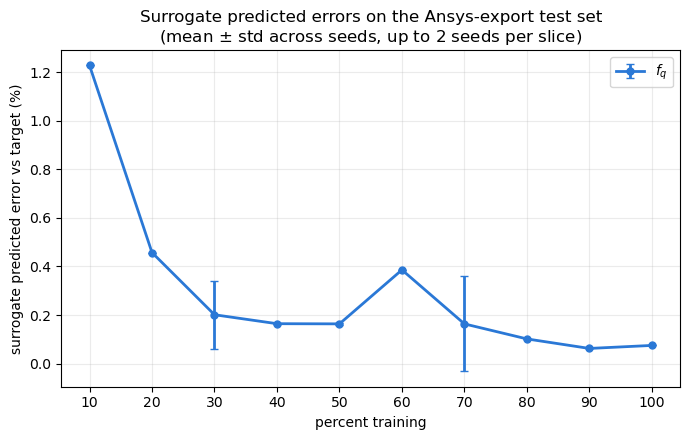

In [44]:
_ANSYS_VAL_DIR = EXPERIMENT_DIR / "results" / "validation" / "data_amount_sweep_heldout_corner_em_sim"
_pred_csvs = sorted(_ANSYS_VAL_DIR.glob("heldout_corner_test_predictions_all_fractions_seed*.csv"))
print(f"Per-seed prediction CSVs found: {[p.name for p in _pred_csvs]}")

_pred_rows = pd.concat([pd.read_csv(p) for p in _pred_csvs], ignore_index=True)
_pred_rows["training_percent"] = _pred_rows["training_percent"].astype(int)
_pred_rows["seed"] = _pred_rows["seed"].astype(int)
print(
    f"Test designs: {len(_pred_rows)} "
    f"(seeds {sorted(_pred_rows['seed'].unique())}, "
    f"training % {sorted(_pred_rows['training_percent'].unique())})"
)

## surrogate_*_pct_error = 100*|pred - ref|/|ref|, recorded by ml_33 for each
## exported design; average per (slice, seed) first so every seed weighs equally
surr_test_by_seed = (
    _pred_rows.groupby(["training_percent", "seed"], as_index=False)
    .agg(
        n_designs=("test_sample_number", "count"),
        fq_pct=("surrogate_frequency_pct_error", "mean"),
        alpha_pct=("surrogate_anharmonicity_pct_error", "mean"),
    )
)

surr_test_summary = (
    surr_test_by_seed.groupby("training_percent")
    .agg(
        n_seeds=("seed", "nunique"),
        n_designs=("n_designs", "sum"),
        fq_pct_mean=("fq_pct", "mean"),
        fq_pct_std=("fq_pct", "std"),
        alpha_pct_mean=("alpha_pct", "mean"),
        alpha_pct_std=("alpha_pct", "std"),
    )
    .reset_index()
)
print(surr_test_summary.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(figsize=(7, 4.5))
for mean_col, std_col, label, color in [
    ("fq_pct_mean", "fq_pct_std", "$f_q$", "#2a78d6"),
    ## ("alpha_pct_mean", "alpha_pct_std", r"$\alpha$", "#e34948"),
]:
    ax.errorbar(
        surr_test_summary["training_percent"],
        surr_test_summary[mean_col],
        yerr=surr_test_summary[std_col].fillna(0.0),
        label=label,
        color=color,
        marker="o",
        markersize=5,
        linewidth=2,
        capsize=3,
    )
ax.set_xticks(surr_test_summary["training_percent"])
ax.set_xlabel("percent training")
ax.set_ylabel("surrogate predicted error vs target (%)")
ax.set_title(
    "Surrogate predicted errors on the EM simulator-export test set\n"
    f"(mean $\\pm$ std across seeds, up to {surr_test_summary['n_seeds'].max()} seeds per slice)"
)
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()